Part a 

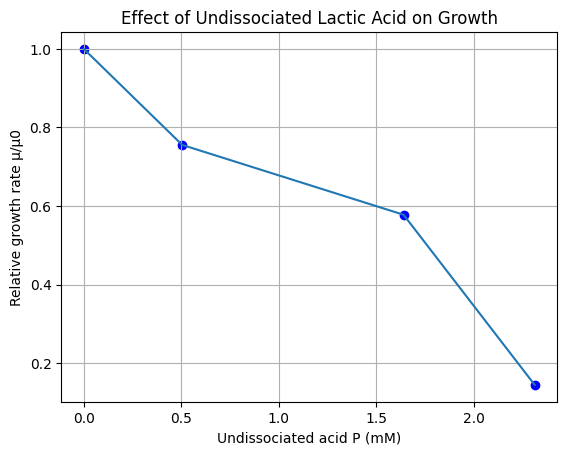

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data
p_gL = np.array([0, 12, 39, 55])   # total lactic acid (g/L)
mu = np.array([0.9, 0.68, 0.52, 0.13])

# Constants
pH = 6.3
pKa = 3.88
M = 90.08   # g/mol

# Convert total acid to mol/L
p_molL = p_gL / M

# Convert to mM
p_mM = p_molL * 1000

# Fraction of undissociated acid
fraction = 1 / (1 + 10**(pH - pKa))

# Undissociated acid concentration
P = p_mM * fraction

# Relative growth rate
mu_rel = mu / mu[0]

# Plot
plt.figure()
plt.scatter(P, mu_rel, color='blue')
plt.plot(P, mu_rel)

plt.xlabel("Undissociated acid P (mM)")
plt.ylabel("Relative growth rate μ/μ0")
plt.title("Effect of Undissociated Lactic Acid on Growth")
plt.grid()

plt.show()

part b

Ki = 0.35585194156583444 mM


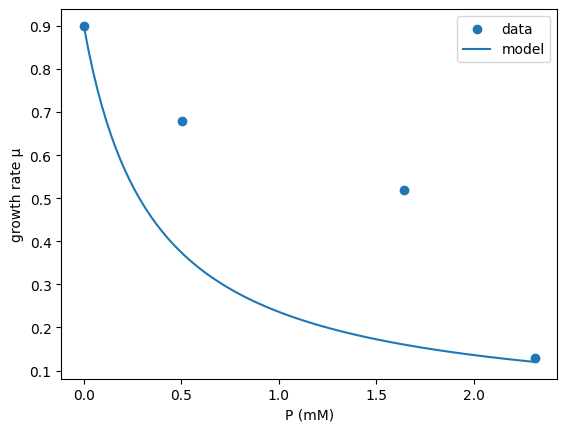

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data
p_gL = np.array([0,12,39,55])
mu = np.array([0.9,0.68,0.52,0.13])

# Constants
pH = 6.3
pKa = 3.88
M = 90.08

# Convert g/L → mol/L
p_mol = p_gL / M

# Convert mol/L → mM
p_mM = p_mol * 1000

# fraction undissociated
fraction = 1/(1+10**(pH-pKa))

# undissociated acid
P = p_mM * fraction

# μmax
mu_max = mu[0]

# Linearization
Y = mu_max/mu - 1

# remove first point (division by zero issue)
P_fit = P[1:]
Y_fit = Y[1:]

# polyfit
a, b = np.polyfit(P_fit, Y_fit,1)

# inhibition constant
Ki = 1/a

print("Ki =",Ki,"mM")

# model curve
P_model = np.linspace(0,max(P),100)

mu_model = mu_max/(1 + P_model/Ki)

# plot
plt.scatter(P,mu,label="data")
plt.plot(P_model,mu_model,label="model")

plt.xlabel("P (mM)")
plt.ylabel("growth rate μ")
plt.legend()
plt.show()

part c

Ki = 0.35585194156583444
Pmax = 3.1348220500148942


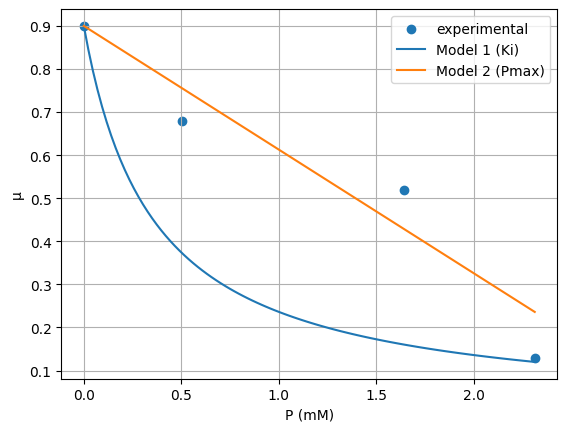

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data
p_gL = np.array([0,12,39,55])
mu = np.array([0.9,0.68,0.52,0.13])

# Constants
pH = 6.3
pKa = 3.88
M = 90.08

# Convert total acid to mM
p_mM = (p_gL/M)*1000

# Undissociated fraction
fraction = 1/(1+10**(pH-pKa))

P = p_mM * fraction

# μmax
mu_max = mu[0]

#################################
# Model 1 (from part b)
#################################

Y1 = mu_max/mu - 1

P_fit = P[1:]
Y1_fit = Y1[1:]

a1,b1 = np.polyfit(P_fit,Y1_fit,1)

Ki = 1/a1

#################################
# Model 2 (this question)
#################################

Y2 = 1 - mu/mu_max

P_fit = P[1:]
Y2_fit = Y2[1:]

a2,b2 = np.polyfit(P_fit,Y2_fit,1)

Pmax = 1/a2

print("Ki =",Ki)
print("Pmax =",Pmax)

#################################
# Create curves
#################################

P_model = np.linspace(0,max(P),100)

# Model 1
mu_model1 = mu_max/(1+P_model/Ki)

# Model 2
mu_model2 = mu_max*(1-P_model/Pmax)

#################################
# Plot
#################################

plt.scatter(P,mu,label="experimental")

plt.plot(P_model,mu_model1,label="Model 1 (Ki)")
plt.plot(P_model,mu_model2,label="Model 2 (Pmax)")

plt.xlabel("P (mM)")
plt.ylabel("μ")
plt.legend()
plt.grid()

plt.show()

part d 

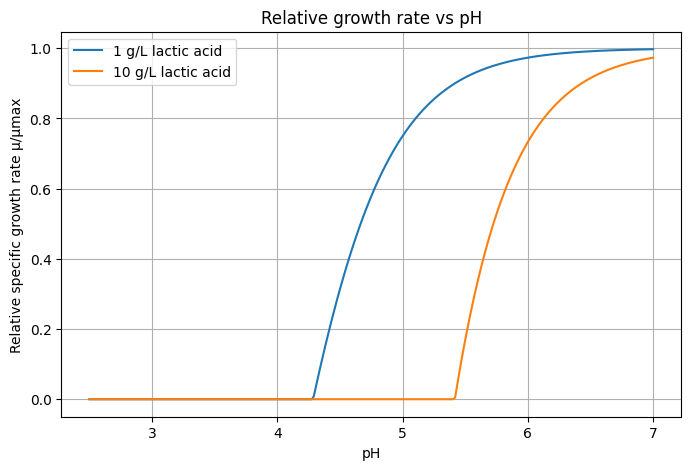

For 1 g/L, growth stops at pH = 4.285981729553904
For 10 g/L, growth stops at pH = 5.417406396276615


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# constants
pKa = 3.88
M = 90.08   # g/mol

# from part (c), use your fitted value
Pmax = 3.13   # mM   <-- replace by your exact computed value if needed

# total lactic acid concentrations (g/L)
c1_gL = 1
c2_gL = 10

# convert to mM
c1_mM = c1_gL / M * 1000
c2_mM = c2_gL / M * 1000

# pH range
pH = np.linspace(2.5, 7.0, 300)

# undissociated acid concentration as a function of pH
P1 = c1_mM / (1 + 10**(pH - pKa))
P2 = c2_mM / (1 + 10**(pH - pKa))

# relative growth rate using model from (c)
mu_rel_1 = 1 - P1 / Pmax
mu_rel_2 = 1 - P2 / Pmax

# optional: clip negative values to zero
mu_rel_1 = np.maximum(mu_rel_1, 0)
mu_rel_2 = np.maximum(mu_rel_2, 0)

# plot
plt.figure(figsize=(8,5))
plt.plot(pH, mu_rel_1, label='1 g/L lactic acid')
plt.plot(pH, mu_rel_2, label='10 g/L lactic acid')

plt.xlabel('pH')
plt.ylabel('Relative specific growth rate μ/μmax')
plt.title('Relative growth rate vs pH')
plt.grid(True)
plt.legend()
plt.show()

# pH at which growth stops
pH_stop_1 = pKa + np.log10(c1_mM / Pmax - 1)
pH_stop_2 = pKa + np.log10(c2_mM / Pmax - 1)

print("For 1 g/L, growth stops at pH =", pH_stop_1)
print("For 10 g/L, growth stops at pH =", pH_stop_2)